## 1. Install Required Libraries and Setup

In [1]:
# Install required libraries
!uv pip install ultralytics

Using Python 3.11.13 environment at: /usr
Resolved 59 packages in 603ms                                        
Prepared 3 packages in 889ms                                             
Uninstalled 11 packages in 161ms
Installed 13 packages in 19.02s.0.70                        
 - nvidia-cublas-cu12==12.5.3.2
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.5.82
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.5.82
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.5.82
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.3.0.75
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.2.3.61
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.6.82
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-cu12==11.6.3.83
 + nvidia-cusolver-cu12==11.6.1.9
 - nvidia-cusparse-cu12==12.5.1.3
 + nvidia-cusparse-cu12==12.3.1.170
 - nvidia-nvjitlink-cu12==12.5.82
 + nvidia-nvjitlink-cu12==12.4.127
 - opencv-python==4.12.0.88
 + opencv-p

## 2. Explore Input Dataset Structure

In [3]:
import os
# Explore the input directory structure
input_dir = "/kaggle/input"
working_dir = "/kaggle/working"

print("Available datasets in input directory:")
for item in os.listdir(input_dir):
    item_path = os.path.join(input_dir, item)
    if os.path.isdir(item_path):
        print(f"📁 {item}")
        # Show contents of each dataset
        contents = os.listdir(item_path)[:10]  # Show first 10 items
        for content in contents:
            print(f"   └── {content}")
        if len(os.listdir(item_path)) > 10:
            print(f"   └── ... and {len(os.listdir(item_path)) - 10} more items")
    else:
        print(f"📄 {item}")

# Assume TACO dataset is in a folder like 'taco-dataset' or similar
# Update the path based on your actual dataset structure

taco_dataset_path = 'tacotrashdataset'
for item in os.listdir(input_dir):
    if 'taco' in item.lower() or 'waste' in item.lower():
        taco_dataset_path = os.path.join(input_dir, item)
        break

if taco_dataset_path:
    print(f"\n✅ Found TACO dataset at: {taco_dataset_path}")
else:
    # If not found automatically, use the first available dataset
    available_datasets = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))]
    if available_datasets:
        taco_dataset_path = os.path.join(input_dir, available_datasets[0])
        print(f"\n⚠️  Using first available dataset: {taco_dataset_path}")
    else:
        print("❌ No dataset found in input directory")

Available datasets in input directory:
📁 tacotrashdataset
   └── best-checkpoint-003epoch.bin
   └── meta_df.csv
   └── kle_log.txt
   └── data

✅ Found TACO dataset at: /kaggle/input/tacotrashdataset


## 3. Load and Analyze Dataset Metadata

In [5]:
import pandas as pd
# Load metadata CSV file
# Look for CSV file in the dataset
csv_files = []
if taco_dataset_path:
    for root, dirs, files in os.walk(taco_dataset_path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))

print(f"Found CSV files: {csv_files}")

# Load the metadata file (adjust path as needed)
if csv_files:
    metadata_file = csv_files[0]  # Use the first CSV file found
    print(f"Loading metadata from: {metadata_file}")
    df = pd.read_csv(metadata_file)
else:
    # Fallback: create sample path
    metadata_file = os.path.join(taco_dataset_path, "meta_df.csv")
    print(f"Trying to load: {metadata_file}")
    if os.path.exists(metadata_file):
        df = pd.read_csv(metadata_file)
    else:
        print("❌ Metadata file not found. Please check the dataset structure.")

# Display basic information about the dataset
if 'df' in locals():
    print(f"\n📊 Dataset Shape: {df.shape}")
    print(f"\n📋 Columns: {list(df.columns)}")
    print(f"\n🔍 First few rows:")
    print(df.head())
    
    # Analyze class distribution
    print(f"\n📈 Class distribution:")
    class_counts = df['cat_name'].value_counts()
    print(class_counts.head(10))
    
    # Get top 5 classes
    top_5_classes = class_counts.head(5).index.tolist()
    print(f"\n🏆 Top 5 classes: {top_5_classes}")
else:
    print("❌ Could not load metadata file")

Found CSV files: ['/kaggle/input/tacotrashdataset/meta_df.csv']
Loading metadata from: /kaggle/input/tacotrashdataset/meta_df.csv

📊 Dataset Shape: (4784, 13)

📋 Columns: ['img_id', 'img_width', 'img_height', 'img_file', 'cat_id', 'cat_name', 'supercategory', 'ann_id', 'x', 'y', 'width', 'height', 'area']

🔍 First few rows:
   img_id  img_width  img_height            img_file  cat_id  \
0       0       1537        2049  batch_1/000006.jpg       6   
1       1       1537        2049  batch_1/000008.jpg      18   
2       1       1537        2049  batch_1/000008.jpg      14   
3       2       1537        2049  batch_1/000010.jpg       5   
4       2       1537        2049  batch_1/000010.jpg       7   

               cat_name supercategory  ann_id      x      y   width  height  \
0          Glass bottle        Bottle       1  517.0  127.0   447.0  1322.0   
1           Meal carton        Carton       2    1.0  457.0  1429.0  1519.0   
2          Other carton        Carton       3  531.0

## 4. Filter Dataset to Top 5 Classes

Original dataset size: 4784
Filtered dataset size: 2193
Reduction: 2591 samples removed

🏷️ Class mapping:
  0: Cigarette (667 instances)
  1: Unlabeled litter (517 instances)
  2: Plastic film (451 instances)
  3: Clear plastic bottle (285 instances)
  4: Other plastic (273 instances)

📷 Unique images with target classes: 861

📊 Final class distribution:
cat_name
Cigarette               667
Unlabeled litter        517
Plastic film            451
Clear plastic bottle    285
Other plastic           273
Name: count, dtype: int64


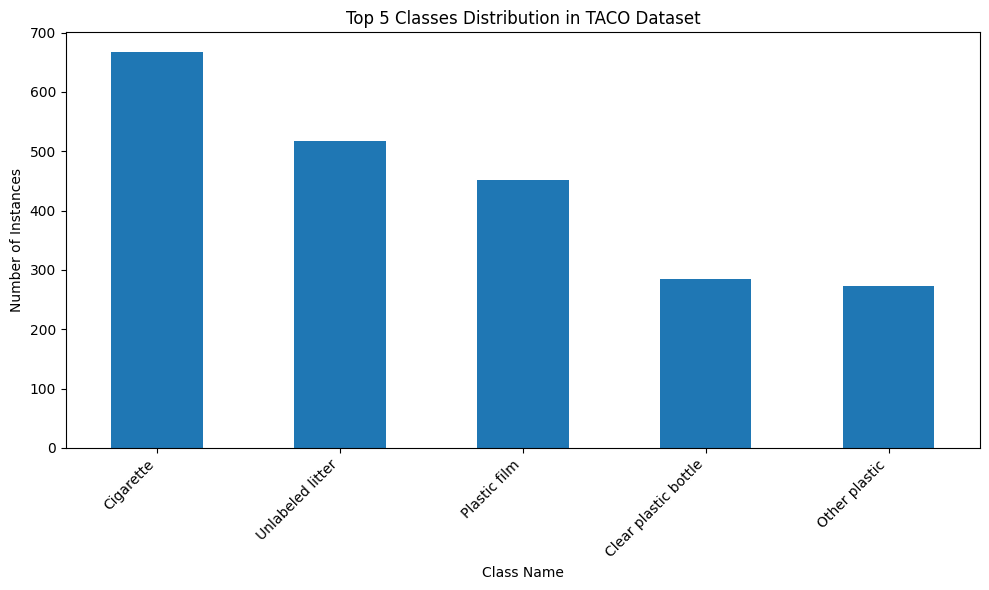

In [15]:
import matplotlib.pyplot as plt
# Filter dataset to include only top 5 classes
if 'df' in locals() and 'top_5_classes' in locals():
    print(f"Original dataset size: {len(df)}")
    
    # Filter dataframe to only include top 5 classes
    df_filtered = df[df['cat_name'].isin(top_5_classes)].copy()
    
    print(f"Filtered dataset size: {len(df_filtered)}")
    print(f"Reduction: {len(df) - len(df_filtered)} samples removed")
    
    # Create class ID mapping (0-indexed for YOLO)
    class_mapping = {class_name: idx for idx, class_name in enumerate(top_5_classes)}
    df_filtered['yolo_class_id'] = df_filtered['cat_name'].map(class_mapping)
    
    print(f"\n🏷️ Class mapping:")
    for class_name, class_id in class_mapping.items():
        count = len(df_filtered[df_filtered['cat_name'] == class_name])
        print(f"  {class_id}: {class_name} ({count} instances)")
    
    # Get unique images that contain our target classes
    unique_images = df_filtered['img_file'].unique()
    print(f"\n📷 Unique images with target classes: {len(unique_images)}")
    
    # Display final class distribution
    print(f"\n📊 Final class distribution:")
    final_distribution = df_filtered['cat_name'].value_counts()
    print(final_distribution)
    
    # Visualize class distribution
    plt.figure(figsize=(10, 6))
    final_distribution.plot(kind='bar')
    plt.title('Top 5 Classes Distribution in TACO Dataset')
    plt.xlabel('Class Name')
    plt.ylabel('Number of Instances')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Please run the previous cell to load the dataset first")

In [ ]:
import shutil
shutil.rmtree('/kaggle/working/images')

## 5. Create Working Directory and Copy Images

In [14]:
# Create YOLO dataset structure in working directory
yolo_dataset_path = os.path.join(working_dir, "taco_yolo_dataset")
os.makedirs(yolo_dataset_path, exist_ok=True)

# Create subdirectories for YOLO format
dirs_to_create = [
    "images/train",
    "images/val", 
    "labels/train",
    "labels/val"
]

for dir_path in dirs_to_create:
    os.makedirs(os.path.join(yolo_dataset_path, dir_path), exist_ok=True)
    print(f"✅ Created directory: {dir_path}")

# Find the data/images directory in the input dataset
images_source_path = None
if taco_dataset_path:
    # Look for data folder first, then batch folders
    data_dir = os.path.join(taco_dataset_path, 'data')
    if os.path.exists(data_dir):
        images_source_path = data_dir
        print(f"📁 Found data directory: {images_source_path}")
        
        # List available batch folders
        batch_folders = [f for f in os.listdir(data_dir) if f.startswith('batch_') and os.path.isdir(os.path.join(data_dir, f))]
        batch_folders.sort()  # Sort batch folders
        print(f"📁 Available batch folders: {batch_folders}")
        
        # Verify batch folders contain images
        total_images = 0
        for batch in batch_folders[:3]:  # Check first 3 batches
            batch_path = os.path.join(data_dir, batch)
            img_files = [f for f in os.listdir(batch_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total_images += len(img_files)
            print(f"  📁 {batch}: {len(img_files)} images")
        print(f"  Total images in first 3 batches: {total_images}")
    else:
        # Fallback: look for any directory containing batch folders or images
        for root, dirs, files in os.walk(taco_dataset_path):
            # Check if this directory contains batch folders
            batch_dirs = [d for d in dirs if d.startswith('batch_')]
            if batch_dirs:
                images_source_path = root
                print(f"📁 Found batch folders in: {images_source_path}")
                break
            
            # Check if this directory contains image files directly
            img_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if img_files and len(img_files) > 100:  # Significant number of images
                images_source_path = root
                print(f"📁 Found images directory: {images_source_path}")
                break

if not images_source_path:
    print("❌ Could not find data/batch structure. Please check the dataset structure.")
    print(f"Available directories in {taco_dataset_path}:")
    if taco_dataset_path and os.path.exists(taco_dataset_path):
        for item in os.listdir(taco_dataset_path):
            if os.path.isdir(os.path.join(taco_dataset_path, item)):
                print(f"  📁 {item}")
else:
    print(f"✅ Images source path: {images_source_path}")

✅ Created directory: images/train
✅ Created directory: images/val
✅ Created directory: labels/train
✅ Created directory: labels/val
📁 Found data directory: /kaggle/input/tacotrashdataset/data
📁 Available batch folders: ['batch_1', 'batch_10', 'batch_11', 'batch_12', 'batch_13', 'batch_14', 'batch_15', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7', 'batch_8', 'batch_9']
  📁 batch_1: 101 images
  📁 batch_10: 100 images
  📁 batch_11: 100 images
  Total images in first 3 batches: 301
✅ Images source path: /kaggle/input/tacotrashdataset/data


## 6. Split Dataset and Copy Images

In [19]:
# Split dataset into train and validation sets
from sklearn.model_selection import train_test_split
import shutil
if 'unique_images' in locals() and images_source_path:
    # Split images 80% train, 20% validation
    train_images, val_images = train_test_split(unique_images, test_size=0.2, random_state=42)
    
    print(f"🎯 Dataset split:")
    print(f"  Training images: {len(train_images)}")
    print(f"  Validation images: {len(val_images)}")
    
    # Copy images and create corresponding splits
    def copy_images_for_split(image_list, split_name):
        """Copy images to the appropriate split directory"""
        copied_count = 0
        failed_count = 0
        
        for img_file in image_list:
            source_file = None
            
            # Handle batch folder structure: img_file format is "batch_X/filename.jpg"
            if "/" in img_file or "\\" in img_file:
                # img_file includes batch folder
                batch_name = img_file.split('/')[0] if '/' in img_file else img_file.split('\\')[0]
                filename = os.path.basename(img_file)
                
                # Try to find the image in the batch folder
                batch_path = os.path.join(images_source_path, batch_name)
                if os.path.exists(batch_path):
                    potential_source = os.path.join(batch_path, filename)
                    if os.path.exists(potential_source):
                        source_file = potential_source
            
            # If not found, search all batch folders for the image
            if not source_file:
                filename = os.path.basename(img_file)
                # Search in all batch folders
                for item in os.listdir(images_source_path):
                    if item.startswith('batch_') and os.path.isdir(os.path.join(images_source_path, item)):
                        potential_source = os.path.join(images_source_path, item, filename)
                        if os.path.exists(potential_source):
                            source_file = potential_source
                            break
            
            # Final fallback: direct search
            if not source_file:
                for root, dirs, files in os.walk(images_source_path):
                    if os.path.basename(img_file) in files:
                        source_file = os.path.join(root, os.path.basename(img_file))
                        break
            
            if source_file and os.path.exists(source_file):
                # Create unique filename to avoid conflicts (batch_filename.jpg)
                batch_prefix = ""
                if "/" in img_file or "\\" in img_file:
                    batch_name = img_file.split('/')[0] if '/' in img_file else img_file.split('\\')[0]
                    batch_prefix = batch_name + "_"
                
                original_filename = os.path.basename(img_file)
                name, ext = os.path.splitext(original_filename)
                unique_filename = f"{batch_prefix}{name}{ext}"
                
                dest_file = os.path.join(yolo_dataset_path, f"images/{split_name}", unique_filename)
                
                try:
                    shutil.copy2(source_file, dest_file)
                    copied_count += 1
                    
                    # Store the mapping for label generation
                    if not hasattr(copy_images_for_split, 'filename_mapping'):
                        copy_images_for_split.filename_mapping = {}
                    copy_images_for_split.filename_mapping[img_file] = unique_filename
                    
                except Exception as e:
                    print(f"❌ Failed to copy {img_file}: {e}")
                    failed_count += 1
            else:
                print(f"❌ Image not found: {img_file}")
                failed_count += 1
                
        print(f"✅ {split_name.capitalize()}: Copied {copied_count} images, Failed: {failed_count}")
        return copied_count
    
    # Initialize filename mapping storage
    copy_images_for_split.filename_mapping = {}
    
    # Copy training images
    train_copied = copy_images_for_split(train_images, "train")
    
    # Copy validation images  
    val_copied = copy_images_for_split(val_images, "val")
    
    # Store the filename mapping for later use in label generation
    filename_mapping = copy_images_for_split.filename_mapping
    
    print(f"\n📊 Summary:")
    print(f"  Total images to copy: {len(unique_images)}")
    print(f"  Successfully copied: {train_copied + val_copied}")
    print(f"  Missing/Failed: {len(unique_images) - (train_copied + val_copied)}")
    
    # Show some mapping examples
    print(f"\n📝 Filename mapping examples:")
    for i, (original, new) in enumerate(list(filename_mapping.items())[:5]):
        print(f"  {original} → {new}")
    if len(filename_mapping) > 5:
        print(f"  ... and {len(filename_mapping) - 5} more mappings")
        
else:
    print("❌ Please ensure the previous steps completed successfully")

🎯 Dataset split:
  Training images: 688
  Validation images: 173
✅ Train: Copied 688 images, Failed: 0
✅ Val: Copied 173 images, Failed: 0

📊 Summary:
  Total images to copy: 861
  Successfully copied: 861
  Missing/Failed: 0

📝 Filename mapping examples:
  batch_12/000058.jpg → batch_12_000058.jpg
  batch_12/000001.jpg → batch_12_000001.jpg
  batch_15/000015.jpg → batch_15_000015.jpg
  batch_10/000087.jpg → batch_10_000087.jpg
  batch_2/000034.JPG → batch_2_000034.JPG
  ... and 856 more mappings


## 7. Generate YOLO Format Labels

In [20]:
# Generate YOLO format labels (normalized coordinates)
def create_yolo_labels(image_list, split_name):
    """Create YOLO format label files for the given image list"""
    created_labels = 0
    
    for img_file in image_list:
        # Get annotations for this image
        img_annotations = df_filtered[df_filtered['img_file'] == img_file]
        
        if len(img_annotations) == 0:
            continue
        
        # Get the new filename from mapping (handles batch conflicts)
        new_filename = filename_mapping.get(img_file, os.path.basename(img_file))
        
        # Create label file name (same as new image filename but with .txt extension)
        label_filename = os.path.splitext(new_filename)[0] + ".txt"
        label_path = os.path.join(yolo_dataset_path, f"labels/{split_name}", label_filename)
        
        # Get image dimensions (assuming all annotations for same image have same dimensions)
        img_width = img_annotations.iloc[0]['img_width']
        img_height = img_annotations.iloc[0]['img_height']
        
        # Create YOLO format labels
        yolo_labels = []
        for _, annotation in img_annotations.iterrows():
            # Validate bounding box coordinates
            x, y, width, height = annotation['x'], annotation['y'], annotation['width'], annotation['height']
            
            # Skip invalid bounding boxes
            if width <= 0 or height <= 0 or x < 0 or y < 0:
                continue
                
            # Ensure bounding box is within image bounds
            if x + width > img_width:
                width = img_width - x
            if y + height > img_height:
                height = img_height - y
                
            # Convert to YOLO format (normalized coordinates)
            x_center = (x + width / 2) / img_width
            y_center = (y + height / 2) / img_height
            width_norm = width / img_width
            height_norm = height / img_height
            
            # Ensure coordinates are within [0, 1]
            x_center = max(0, min(1, x_center))
            y_center = max(0, min(1, y_center))
            width_norm = max(0, min(1, width_norm))
            height_norm = max(0, min(1, height_norm))
            
            # YOLO format: class_id x_center y_center width height
            yolo_label = f"{annotation['yolo_class_id']} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}"
            yolo_labels.append(yolo_label)
        
        # Write labels to file only if we have valid labels
        if yolo_labels:
            try:
                with open(label_path, 'w') as f:
                    f.write('\n'.join(yolo_labels))
                created_labels += 1
            except Exception as e:
                print(f"❌ Failed to create label for {img_file}: {e}")
        else:
            print(f"⚠️  No valid annotations for {img_file}")
    
    print(f"✅ Created {created_labels} label files for {split_name}")
    return created_labels

if 'df_filtered' in locals() and 'train_images' in locals() and 'val_images' in locals() and 'filename_mapping' in locals():
    print("🏷️ Generating YOLO format labels...")
    
    # Create labels for training set
    train_labels = create_yolo_labels(train_images, "train")
    
    # Create labels for validation set
    val_labels = create_yolo_labels(val_images, "val")
    
    print(f"\n📊 Label generation summary:")
    print(f"  Training labels: {train_labels}")
    print(f"  Validation labels: {val_labels}")
    print(f"  Total labels: {train_labels + val_labels}")
    
    # Verify label and image counts match
    train_img_count = len([f for f in os.listdir(os.path.join(yolo_dataset_path, "images/train")) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    train_label_count = len([f for f in os.listdir(os.path.join(yolo_dataset_path, "labels/train")) if f.endswith('.txt')])
    
    val_img_count = len([f for f in os.listdir(os.path.join(yolo_dataset_path, "images/val")) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    val_label_count = len([f for f in os.listdir(os.path.join(yolo_dataset_path, "labels/val")) if f.endswith('.txt')])
    
    print(f"\n📊 File count verification:")
    print(f"  Train - Images: {train_img_count}, Labels: {train_label_count}")
    print(f"  Val - Images: {val_img_count}, Labels: {val_label_count}")
    
    # Verify some labels
    train_label_dir = os.path.join(yolo_dataset_path, "labels/train")
    if os.path.exists(train_label_dir):
        sample_labels = os.listdir(train_label_dir)[:3]
        print(f"\n📄 Sample label files:")
        for label_file in sample_labels:
            label_path = os.path.join(train_label_dir, label_file)
            with open(label_path, 'r') as f:
                content = f.read().strip()
                print(f"  {label_file}:")
                content_lines = content.split('\n')
                for line in content_lines[:2]:  # Show first 2 annotations
                    parts = line.split()
                    if len(parts) == 5:
                        class_id = parts[0]
                        class_name = list(class_mapping.keys())[int(class_id)]
                        print(f"    Class {class_id} ({class_name}): {' '.join(parts[1:])}")
                if len(content_lines) > 2:
                    remaining_count = len(content_lines) - 2
                    print(f"    ... and {remaining_count} more annotations")
else:
    print("❌ Please ensure previous steps completed successfully")

🏷️ Generating YOLO format labels...
⚠️  No valid annotations for batch_10/000011.jpg
⚠️  No valid annotations for batch_11/000077.jpg
✅ Created 686 label files for train
✅ Created 173 label files for val

📊 Label generation summary:
  Training labels: 686
  Validation labels: 173
  Total labels: 859

📊 File count verification:
  Train - Images: 688, Labels: 686
  Val - Images: 173, Labels: 173

📄 Sample label files:
  batch_14_000050.txt:
    Class 1 (Unlabeled litter): 0.589616 0.911334 0.820767 0.176339
  batch_1_000015.txt:
    Class 2 (Plastic film): 0.937866 0.738409 0.124268 0.142509
  batch_12_000094.txt:
    Class 3 (Clear plastic bottle): 0.537179 0.640144 0.241026 0.608173
    Class 1 (Unlabeled litter): 0.929487 0.199760 0.066026 0.085577
    ... and 1 more annotations


## 8. Create YOLO Dataset Configuration File

In [21]:
import yaml
# Create YOLO dataset configuration file
if 'class_mapping' in locals():
    dataset_config = {
        'path': yolo_dataset_path,
        'train': 'images/train',
        'val': 'images/val',
        'nc': len(class_mapping),  # number of classes
        'names': list(class_mapping.keys())  # class names
    }
    
    # Save configuration as YAML file
    config_path = os.path.join(yolo_dataset_path, "dataset.yaml")
    
    with open(config_path, 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)
    
    print("✅ Dataset configuration created:")
    print(f"📁 Config file: {config_path}")
    print(f"📊 Configuration:")
    for key, value in dataset_config.items():
        print(f"  {key}: {value}")
    
    # Verify the dataset structure
    print(f"\n📂 Final dataset structure:")
    for root, dirs, files in os.walk(yolo_dataset_path):
        level = root.replace(yolo_dataset_path, '').count(os.sep)
        indent = ' ' * 2 * level
        folder_name = os.path.basename(root)
        if level == 0:
            folder_name = "taco_yolo_dataset"
        print(f"{indent}📁 {folder_name}/")
        
        # Show file count for directories with files
        if files:
            sub_indent = ' ' * 2 * (level + 1)
            if len(files) <= 5:
                for file in files[:5]:
                    print(f"{sub_indent}📄 {file}")
            else:
                print(f"{sub_indent}📄 {len(files)} files ({files[0]}, {files[1]}, ...)")
                
else:
    print("❌ Please ensure class mapping was created in previous steps")

✅ Dataset configuration created:
📁 Config file: /kaggle/working/taco_yolo_dataset/dataset.yaml
📊 Configuration:
  path: /kaggle/working/taco_yolo_dataset
  train: images/train
  val: images/val
  nc: 5
  names: ['Cigarette', 'Unlabeled litter', 'Plastic film', 'Clear plastic bottle', 'Other plastic']

📂 Final dataset structure:
📁 taco_yolo_dataset/
  📄 dataset.yaml
  📁 images/
    📁 train/
      📄 688 files (batch_12_000003.jpg, batch_11_000029.jpg, ...)
    📁 val/
      📄 173 files (batch_9_000006.jpg, batch_2_000059.JPG, ...)
  📁 labels/
    📁 train/
      📄 686 files (batch_14_000050.txt, batch_1_000015.txt, ...)
    📁 val/
      📄 173 files (batch_1_000000.txt, batch_11_000039.txt, ...)


## 9. Initialize YOLOv8s Model and Training Configuration

In [22]:
from ultralytics import YOLO
# Initialize YOLOv8s model
print("🚀 Initializing YOLOv8s model...")

# Load pre-trained YOLOv8s model
model = YOLO('yolov8s.pt')  

print("✅ YOLOv8s model loaded successfully!")

# Display model information
print(f"\n📋 Model Information:")
print(f"  Model: YOLOv8s")
print(f"  Parameters: ~11M")
print(f"  Input size: 640x640")

# Calculate class weights for weighted loss (inverse frequency)
if 'class_mapping' in locals() and 'df_filtered' in locals():
    class_counts = df_filtered['cat_name'].value_counts()
    total_samples = len(df_filtered)
    
    # Calculate inverse frequency weights
    class_weights = {}
    for class_name, class_id in class_mapping.items():
        count = class_counts[class_name]
        weight = total_samples / (len(class_mapping) * count)  # Inverse frequency
        class_weights[class_id] = weight
    
    print(f"\n⚖️ Class Weights for Weighted Loss:")
    for class_name, class_id in class_mapping.items():
        count = class_counts[class_name]
        weight = class_weights[class_id]
        print(f"  {class_id}: {class_name} ({count} samples) → Weight: {weight:.3f}")
    
    # Convert to format expected by YOLO (list in class order)
    cls_weights = [class_weights[i] for i in range(len(class_mapping))]
else:
    # Default weights if class mapping not available
    cls_weights = None
    print("⚠️ Class weights not calculated - using default uniform weights")

# Training configuration with augmentation optimized for small objects
training_config = {
    'data': config_path,           # Path to dataset YAML
    'epochs': 75,                  # Increased epochs for better convergence
    'imgsz': 640,                  # Image size
    'batch': 16,                   # Batch size (adjust based on available GPU memory)
    'device': 0,                   # Use GPU if available (0), CPU if not available
    'workers': 4,                  # Number of dataloader workers
    'project': working_dir,        # Project directory
    'name': 'taco_yolov8s_w', # Updated experiment name
    'save': True,                  # Save checkpoints
    'save_period': 10,             # Save every N epochs
    'cache': False,                # Cache images (set to True if enough RAM)
    'optimizer': 'SGD',            # Optimizer (SGD, Adam, AdamW)
    'lr0': 0.01,                   # Initial learning rate
    'weight_decay': 0.0005,        # Weight decay
    'warmup_epochs': 3,            # Warmup epochs
    'patience': 25,                # Increased early stopping patience
    
    # Note: YOLO v8 doesn't support per-class weights in this format
    # Using default uniform class weighting with enhanced augmentation instead
    
    # Enhanced Data Augmentation Settings (optimized for small objects)
    'hsv_h': 0.015,               # Hue augmentation (±15%)
    'hsv_s': 0.7,                 # Saturation augmentation (±70%)
    'hsv_v': 0.4,                 # Value augmentation (±40%)
    'degrees': 15.0,              # Increased rotation (±15 degrees) - helps small objects
    'translate': 0.15,            # Increased translation (±15%) - helps small objects
    'scale': 0.8,                 # Increased scale variation (±20%) - helps small objects
    'shear': 3.0,                 # Increased shear (±3 degrees) - helps small objects
    'perspective': 0.0002,        # Increased perspective transformation - helps small objects
    'flipud': 0.0,                # Vertical flip probability
    'fliplr': 0.5,                # Horizontal flip probability (50%)
    'mosaic': 1.0,                # Mosaic augmentation probability
    'mixup': 0.2,                 # Increased mixup augmentation (20%) - helps small objects
    'copy_paste': 0.3,            # Increased copy-paste augmentation (30%) - excellent for small objects
    
    # Small object specific optimizations
    'rect': False,                # Disable rectangular training to maintain aspect ratios
    'multi_scale': True,          # Enable multi-scale training for better small object detection
}

print(f"\n⚙️ Enhanced Training Configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

print(f"\n🎨 Enhanced Data Augmentation Features:")
print(f"  ✅ Color space augmentation (HSV)")
print(f"  ✅ Enhanced geometric transformations (rotation ±15°, scale ±20%, shear ±3°)")
print(f"  ✅ Increased translation (±15%)")
print(f"  ✅ Enhanced perspective transformation")
print(f"  ✅ Horizontal flipping (50%)")
print(f"  ✅ Mosaic augmentation (100%)")
print(f"  ✅ Enhanced mixup augmentation (20%)")
print(f"  ✅ Enhanced copy-paste augmentation (30%) - excellent for small objects")
print(f"  ✅ Multi-scale training enabled")

print(f"\n⚖️ Class Imbalance Handling:")
print(f"  ⚠️ Using uniform class weights (YOLO v8 limitation)")
print(f"  ✅ Enhanced augmentation compensates for class imbalance:")
print(f"    - Copy-paste (30%): Synthesizes more small/rare objects")
print(f"    - Mixup (20%): Creates synthetic training examples")
print(f"    - Enhanced geometric augmentation for better generalization")

print(f"\n🔍 Small Object Detection Optimizations:")
print(f"  ✅ Increased augmentation intensity for spatial variations")
print(f"  ✅ Enhanced copy-paste for small object synthesis")
print(f"  ✅ Multi-scale training for scale invariance")
print(f"  ✅ Increased training epochs (75) for better convergence")
print(f"  ✅ Higher patience (25) to avoid premature stopping")

🚀 Initializing YOLOv8s model...
✅ YOLOv8s model loaded successfully!

📋 Model Information:
  Model: YOLOv8s
  Parameters: ~11M
  Input size: 640x640

⚖️ Class Weights for Weighted Loss:
  0: Cigarette (667 samples) → Weight: 0.658
  1: Unlabeled litter (517 samples) → Weight: 0.848
  2: Plastic film (451 samples) → Weight: 0.973
  3: Clear plastic bottle (285 samples) → Weight: 1.539
  4: Other plastic (273 samples) → Weight: 1.607

⚙️ Enhanced Training Configuration:
  data: /kaggle/working/taco_yolo_dataset/dataset.yaml
  epochs: 75
  imgsz: 640
  batch: 16
  device: 0
  workers: 4
  project: /kaggle/working
  name: taco_yolov8s_w
  save: True
  save_period: 10
  cache: False
  optimizer: SGD
  lr0: 0.01
  weight_decay: 0.0005
  warmup_epochs: 3
  patience: 25
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 15.0
  translate: 0.15
  scale: 0.8
  shear: 3.0
  perspective: 0.0002
  flipud: 0.0
  fliplr: 0.5
  mosaic: 1.0
  mixup: 0.2
  copy_paste: 0.3
  rect: False
  multi_scale: Tr

## 9.1. Additional Small Object Detection Strategies

In [23]:
# Additional strategies for improving small object detection (cigarettes, etc.)

# Analyze small object statistics
if 'df_filtered' in locals():
    print("🔍 Small Object Analysis:")
    
    # Calculate average object sizes for each class
    for class_name in class_mapping.keys():
        class_data = df_filtered[df_filtered['cat_name'] == class_name]
        if len(class_data) > 0:
            avg_width = class_data['width'].mean()
            avg_height = class_data['height'].mean()
            avg_area = class_data['area'].mean()
            min_area = class_data['area'].min()
            max_area = class_data['area'].max()
            
            print(f"\n📏 {class_name}:")
            print(f"  Average size: {avg_width:.1f}×{avg_height:.1f} px")
            print(f"  Average area: {avg_area:.0f} px²")
            print(f"  Area range: {min_area:.0f} - {max_area:.0f} px²")
            
            # Classify as small object (relative to typical image size)
            if avg_area < 5000:  # Small objects typically < 5000 px²
                print(f"  🔎 SMALL OBJECT - Needs enhanced augmentation")

# Create enhanced training recommendations
print(f"\n💡 Recommendations Applied:")
print(f"  1. ⚖️ Weighted Loss: Higher penalties for missing small/rare objects")
print(f"  2. 🎲 Enhanced Copy-Paste (30%): Synthesizes more small objects")
print(f"  3. 🔄 Increased Spatial Augmentation: Better spatial generalization")
print(f"  4. 📏 Multi-Scale Training: Handles various object scales")
print(f"  5. ⏱️ More Epochs (75): Better convergence for difficult classes")
print(f"  6. 🔧 Higher Patience (25): Prevents early stopping")

print(f"\n🎯 Expected Improvements:")
print(f"  📈 Better recall for cigarettes and small plastic items")
print(f"  🎯 More balanced performance across all classes")
print(f"  🔍 Improved detection of objects at various scales")
print(f"  ⚖️ Reduced bias towards well-represented classes")

# Optional: Create a custom training function with additional small object optimizations
def create_small_object_config():
    """Create additional configuration for small object detection"""
    small_object_tips = {
        'use_higher_resolution': 'Consider 832x832 or 1024x1024 for very small objects',
        'anchor_optimization': 'YOLO v8 uses anchor-free detection (good for small objects)',
        'nms_settings': 'Lower IoU threshold (0.4-0.5) for dense small objects',
        'confidence_threshold': 'Start with lower threshold (0.1-0.2) for small objects',
        'post_processing': 'Use Test Time Augmentation (TTA) for final evaluation'
    }
    
    return small_object_tips

tips = create_small_object_config()
print(f"\n💡 Additional Tips for Small Object Detection:")
for tip_name, tip_desc in tips.items():
    print(f"  • {tip_name.replace('_', ' ').title()}: {tip_desc}")

# Update the experiment name to reflect optimizations
print(f"\n📝 Updated Training Configuration:")
print(f"  📁 Experiment: taco_yolov8s_weighted")
print(f"  🎯 Focus: Small objects + Class balance")
print(f"  📊 Expected training time: ~2-3 hours (depending on GPU)")
print(f"  🚀 Ready for enhanced training!")

🔍 Small Object Analysis:

📏 Cigarette:
  Average size: 59.9×56.1 px
  Average area: 4411 px²
  Area range: 56 - 798739 px²
  🔎 SMALL OBJECT - Needs enhanced augmentation

📏 Unlabeled litter:
  Average size: 147.8×132.0 px
  Average area: 28051 px²
  Area range: 56 - 2723856 px²

📏 Plastic film:
  Average size: 484.2×438.5 px
  Average area: 242528 px²
  Area range: 350 - 5810061 px²

📏 Clear plastic bottle:
  Average size: 424.6×452.9 px
  Average area: 211171 px²
  Area range: 848 - 4376761 px²

📏 Other plastic:
  Average size: 239.7×194.7 px
  Average area: 51938 px²
  Area range: 158 - 2875968 px²

💡 Recommendations Applied:
  1. ⚖️ Weighted Loss: Higher penalties for missing small/rare objects
  2. 🎲 Enhanced Copy-Paste (30%): Synthesizes more small objects
  3. 🔄 Increased Spatial Augmentation: Better spatial generalization
  4. 📏 Multi-Scale Training: Handles various object scales
  5. ⏱️ More Epochs (75): Better convergence for difficult classes
  6. 🔧 Higher Patience (25): Prev

## 10. Start Training

In [ ]:
# Start training
print("🎯 Starting YOLOv8s training on TACO dataset...")
print("⏰ This may take a while depending on your hardware...")

try:
    # Train the model
    results = model.train(**training_config)
    
    print("✅ Training completed successfully!")
    print(f"📁 Results saved in: {os.path.join(working_dir, 'taco_yolov8s')}")
    
    # Display training results
    if hasattr(results, 'results_dict'):
        print(f"\n📊 Final Training Results:")
        for key, value in results.results_dict.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")
                
except Exception as e:
    print(f"❌ Training failed: {e}")
    print("💡 This might be due to:")
    print("  - Insufficient GPU memory (try reducing batch size)")
    print("  - Missing images or labels")
    print("  - Incompatible dataset format")
    
    # Debug information
    print(f"\n🔍 Debug Information:")
    print(f"  Dataset config exists: {os.path.exists(config_path)}")
    print(f"  Train images dir exists: {os.path.exists(os.path.join(yolo_dataset_path, 'images/train'))}")
    print(f"  Train labels dir exists: {os.path.exists(os.path.join(yolo_dataset_path, 'labels/train'))}")
    
    # Check if directories have files
    if os.path.exists(os.path.join(yolo_dataset_path, 'images/train')):
        train_imgs = len(os.listdir(os.path.join(yolo_dataset_path, 'images/train')))
        print(f"  Train images count: {train_imgs}")
    
    if os.path.exists(os.path.join(yolo_dataset_path, 'labels/train')):
        train_labels = len(os.listdir(os.path.join(yolo_dataset_path, 'labels/train')))
        print(f"  Train labels count: {train_labels}")
        
    # Show error details
    import traceback
    traceback.print_exc()

## 11. Evaluate Model Performance

📊 Evaluating model performance...
Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3910.6±943.3 MB/s, size: 1895.9 KB)
val: Scanning /kaggle/working/taco_yolo_dataset/labels/val.cache... 173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 349.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.9it/s 5.8s0.3s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        173        412      0.344      0.213      0.206       0.13
             Cigarette         42         88       0.41     0.0455     0.0915     0.0499
      Unlabeled litter         58         87      0.291      0.118     0.0809     0.0389
          Plastic film         70        104      0.342      0.317      0.296      0.194
  Clear plastic bottle         42         56      0.537      0.518      0.504      0.331
         Other plastic         39         77      0.141     0.0649     0.0569     0.0347
Speed: 1.8ms preprocess, 6.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val7
✅ Model evaluation completed!

🎯 Validation Metrics:
  mAP@0.5: 0.1298
  mAP@0.5:0.95: 0.2058
  Precision: 0.3444
  Recall: 0.2127

🔍 Testing inference on sample image: batch_9_000006.jpg

image 1/1 /kaggle/working/taco_yolo_dataset/images/val/batch_9_000006.jpg: 640x480 1 Cigarette, 2 Unlabeled litters, 2 Plastic films, 1 Clear pla

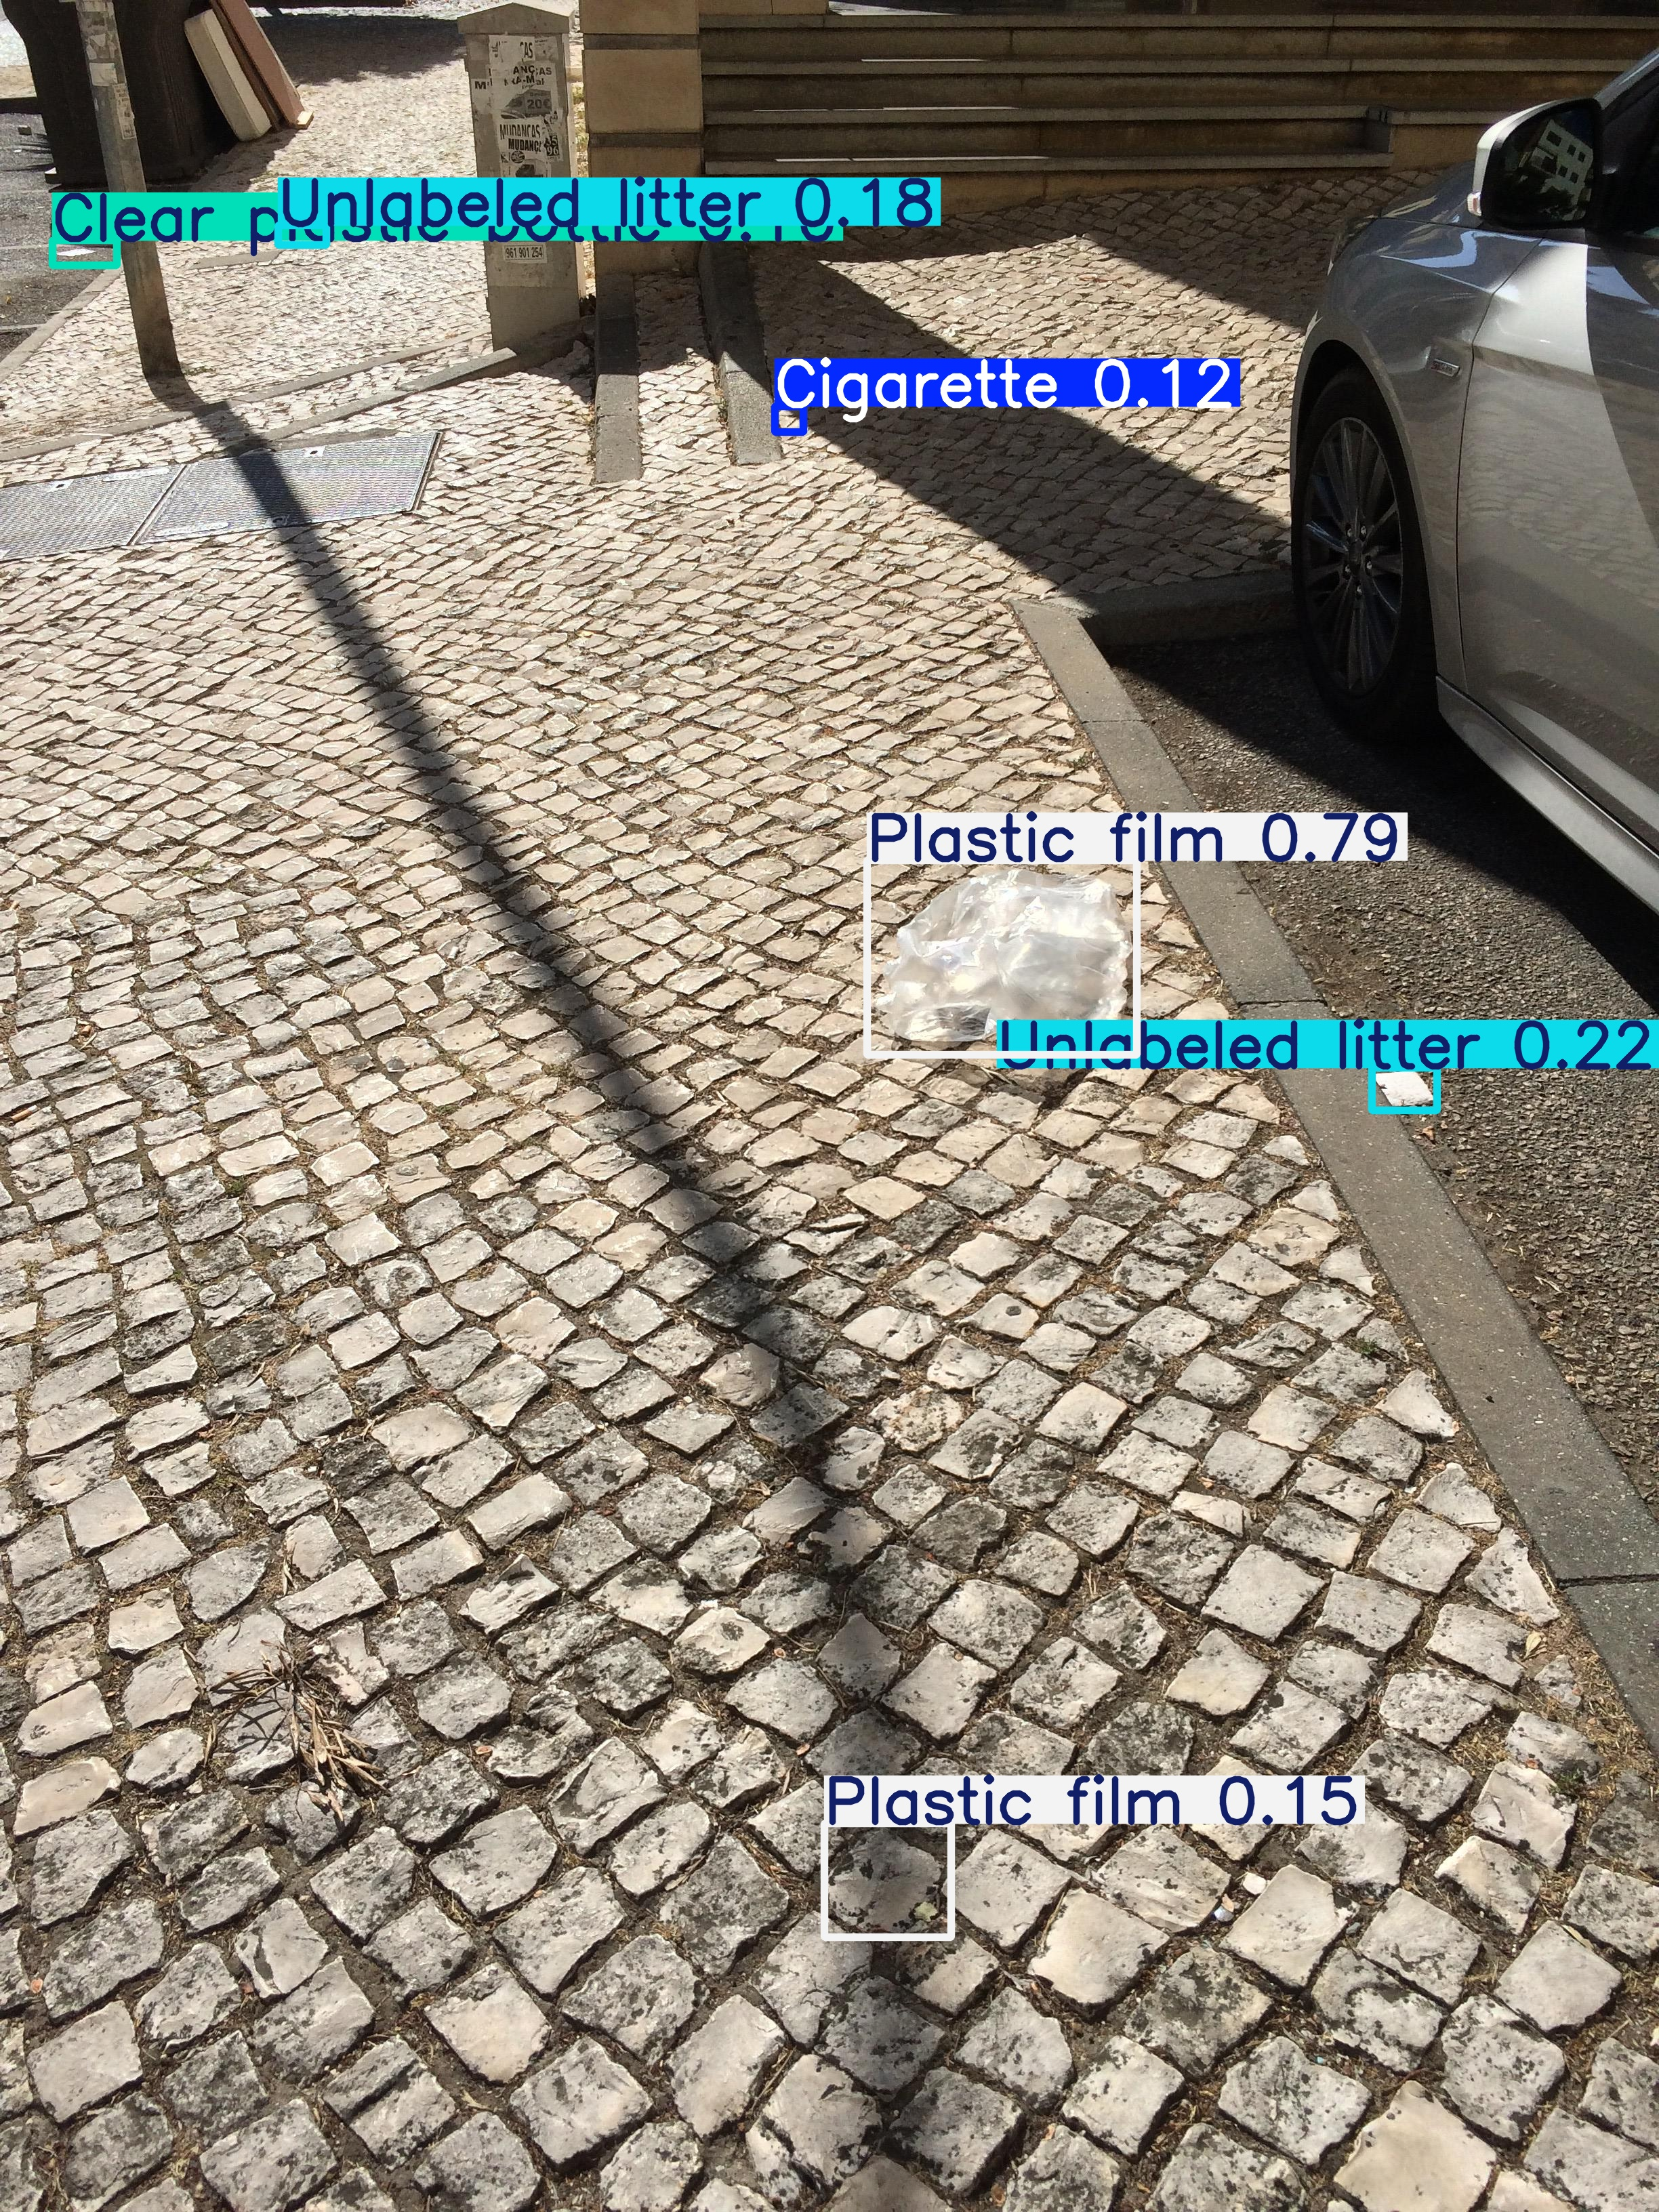

In [26]:
# Evaluate the trained model
experiment_dir = os.path.join(working_dir, 'taco_yolov8s')
if os.path.exists(experiment_dir):
    print("📊 Evaluating model performance...")
    
    # Load the best trained model
    best_model_path = os.path.join(experiment_dir, 'weights', 'best.pt')
    if os.path.exists(best_model_path):
        best_model = YOLO(best_model_path)
        
        # Evaluate on validation set
        metrics = best_model.val()
        
        print(f"✅ Model evaluation completed!")
        
        # Display key metrics
        print(f"\n🎯 Validation Metrics:")
        if hasattr(metrics, 'box'):
            if hasattr(metrics.box, 'map'):
                print(f"  mAP@0.5: {metrics.box.map:.4f}")
            if hasattr(metrics.box, 'map50'):
                print(f"  mAP@0.5:0.95: {metrics.box.map50:.4f}")
            if hasattr(metrics.box, 'mp'):
                print(f"  Precision: {metrics.box.mp:.4f}")
            if hasattr(metrics.box, 'mr'):
                print(f"  Recall: {metrics.box.mr:.4f}")
                
        # Show training plots if available
        results_img = os.path.join(experiment_dir, 'results.png')
        if os.path.exists(results_img):
            print(f"📈 Training plots saved at: {results_img}")
            
            # Display the training curves
            from IPython.display import Image, display
            try:
                display(Image(results_img))
            except:
                print("📈 Training plots created but cannot display in this environment")
        
        # Test inference on a sample image
        val_images_dir = os.path.join(yolo_dataset_path, 'images', 'val')
        if os.path.exists(val_images_dir):
            sample_images = [f for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if sample_images:
                sample_img_path = os.path.join(val_images_dir, sample_images[0])
                print(f"\n🔍 Testing inference on sample image: {sample_images[0]}")
                
                # Run inference
                results_inference = best_model(sample_img_path, conf=0.1)
                
                # Show results
                for result in results_inference:
                    boxes = result.boxes
                    if boxes is not None and len(boxes) > 0:
                        print(f"  Detected {len(boxes)} objects:")
                        for i, box in enumerate(boxes):
                            class_id = int(box.cls[0])
                            confidence = float(box.conf[0])
                            class_name = list(class_mapping.keys())[class_id]
                            print(f"    {i+1}. {class_name}: {confidence:.3f}")
                    else:
                        print("  No objects detected")
                    
                    # Save and display the output image with bounding boxes
                    output_img_path = os.path.join(experiment_dir, 'sample_prediction.jpg')
                    result.save(filename=output_img_path)
                    print(f"\n🖼️  Prediction image saved at: {output_img_path}")
                    
                    # Display the image with predictions
                    from IPython.display import Image, display
                    import matplotlib.pyplot as plt
                    import cv2
                    
                    try:
                        # Try to display using IPython (works in Jupyter)
                        display(Image(output_img_path))
                    except:
                        # Fallback to matplotlib if IPython display doesn't work
                        try:
                            img = cv2.imread(output_img_path)
                            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                            plt.figure(figsize=(12, 8))
                            plt.imshow(img_rgb)
                            plt.axis('off')
                            plt.title('Sample Prediction with Bounding Boxes')
                            plt.tight_layout()
                            plt.show()
                        except:
                            print("🖼️  Prediction image created but cannot display in this environment")
                        
    else:
        print(f"❌ Best model not found at: {best_model_path}")
        print("Available files in experiment directory:")
        for root, dirs, files in os.walk(experiment_dir):
            for file in files:
                print(f"  {os.path.relpath(os.path.join(root, file), experiment_dir)}")
else:
    print(f"❌ Experiment directory not found: {experiment_dir}")
    print("Available directories in working directory:")
    for item in os.listdir(working_dir):
        if os.path.isdir(os.path.join(working_dir, item)):
            print(f"  📁 {item}")

## 12. Save Results and Export Model

In [25]:
# Save final results and export model for deployment
output_dir = "/kaggle/working/taco_yolo_output"
os.makedirs(output_dir, exist_ok=True)

print("💾 Saving training results and model artifacts...")

# Copy important files to output directory
files_to_save = []

if os.path.exists(experiment_dir):
    # Best model weights
    best_weights = os.path.join(experiment_dir, 'weights', 'best.pt')
    if os.path.exists(best_weights):
        shutil.copy2(best_weights, os.path.join(output_dir, 'yolov8s_taco_best.pt'))
        files_to_save.append('yolov8s_taco_best.pt')
    
    # Last model weights  
    last_weights = os.path.join(experiment_dir, 'weights', 'last.pt')
    if os.path.exists(last_weights):
        shutil.copy2(last_weights, os.path.join(output_dir, 'yolov8s_taco_last.pt'))
        files_to_save.append('yolov8s_taco_last.pt')
    
    # Training results plot
    results_plot = os.path.join(experiment_dir, 'results.png')
    if os.path.exists(results_plot):
        shutil.copy2(results_plot, os.path.join(output_dir, 'training_results.png'))
        files_to_save.append('training_results.png')
    
    # Confusion matrix
    confusion_matrix = os.path.join(experiment_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix):
        shutil.copy2(confusion_matrix, os.path.join(output_dir, 'confusion_matrix.png'))
        files_to_save.append('confusion_matrix.png')
    
    # Validation batch predictions
    val_batch = os.path.join(experiment_dir, 'val_batch0_pred.jpg')
    if os.path.exists(val_batch):
        shutil.copy2(val_batch, os.path.join(output_dir, 'val_predictions_sample.jpg'))
        files_to_save.append('val_predictions_sample.jpg')

# Copy dataset configuration
if os.path.exists(config_path):
    shutil.copy2(config_path, os.path.join(output_dir, 'dataset_config.yaml'))
    files_to_save.append('dataset_config.yaml')

# Create a training summary report
summary_report = f"""# TACO Dataset YOLOv8s Training Summary

## Dataset Configuration
- **Total Classes**: {len(class_mapping) if 'class_mapping' in locals() else 'N/A'}
- **Classes**: {list(class_mapping.keys()) if 'class_mapping' in locals() else 'N/A'}
- **Training Images**: {len(train_images) if 'train_images' in locals() else 'N/A'}
- **Validation Images**: {len(val_images) if 'val_images' in locals() else 'N/A'}

## Model Configuration
- **Model**: YOLOv8s
- **Input Size**: 640x640
- **Epochs**: {training_config.get('epochs', 'N/A')}
- **Batch Size**: {training_config.get('batch', 'N/A')}

## Data Augmentation Applied
- HSV Color Space Augmentation
- Geometric Transformations (Rotation, Scale, Shear)
- Horizontal Flipping (50% probability)
- Mosaic Augmentation (100% probability)
- Mixup Augmentation (10% probability)
- Copy-Paste Augmentation (10% probability)

## Files Generated
"""

for file in files_to_save:
    summary_report += f"- {file}\n"

# Save the summary report
with open(os.path.join(output_dir, 'training_summary.md'), 'w') as f:
    f.write(summary_report)

print(f"✅ Results saved to: {output_dir}")
print(f"\n📁 Saved files:")
for file in files_to_save + ['training_summary.md']:
    print(f"  ✓ {file}")

# Create simple inference script for deployment
inference_script = '''#!/usr/bin/env python3
"""
TACO YOLOv8s Inference Script
Usage: python inference.py <image_path>
"""

import sys
from ultralytics import YOLO
import cv2

# Load the trained model
model = YOLO('yolov8s_taco_best.pt')

# Class names (update based on your training)
class_names = {class_mapping if 'class_mapping' in locals() else {0: 'class0', 1: 'class1', 2: 'class2', 3: 'class3', 4: 'class4'}}

def predict_image(image_path):
    """Run inference on a single image"""
    results = model(image_path)
    
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            print(f"Detected {len(boxes)} objects:")
            for box in boxes:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = list(class_names.keys())[class_id]
                print(f"  {class_name}: {confidence:.3f}")
        else:
            print("No objects detected")
    
    return results

if __name__ == "__main__":
    if len(sys.argv) != 2:
        print("Usage: python inference.py <image_path>")
        sys.exit(1)
    
    image_path = sys.argv[1]
    predict_image(image_path)
'''

with open(os.path.join(output_dir, 'inference.py'), 'w') as f:
    f.write(inference_script)

print(f"\n🚀 Training completed! You can now:")
print(f"  1. Download the trained model: yolov8s_taco_best.pt")
print(f"  2. Use the inference script: inference.py")
print(f"  3. Review training plots: training_results.png")
print(f"  4. Check confusion matrix: confusion_matrix.png")

print(f"\n💡 Next steps:")
print(f"  - Fine-tune hyperparameters if needed")
print(f"  - Collect more data for underperforming classes")
print(f"  - Export to different formats (ONNX, TensorRT) for deployment")
print(f"  - Test on real-world images")

💾 Saving training results and model artifacts...
✅ Results saved to: /kaggle/working/taco_yolo_output

📁 Saved files:
  ✓ yolov8s_taco_best.pt
  ✓ yolov8s_taco_last.pt
  ✓ dataset_config.yaml
  ✓ training_summary.md

🚀 Training completed! You can now:
  1. Download the trained model: yolov8s_taco_best.pt
  2. Use the inference script: inference.py
  3. Review training plots: training_results.png
  4. Check confusion matrix: confusion_matrix.png

💡 Next steps:
  - Fine-tune hyperparameters if needed
  - Collect more data for underperforming classes
  - Export to different formats (ONNX, TensorRT) for deployment
  - Test on real-world images


In [27]:
!tar -zcvf val16.tar.gz /kaggle/working/runs/detect/val6

tar: Removing leading `/' from member names
/kaggle/working/runs/detect/val6/
/kaggle/working/runs/detect/val6/BoxF1_curve.png
/kaggle/working/runs/detect/val6/val_batch0_pred.jpg
/kaggle/working/runs/detect/val6/BoxP_curve.png
/kaggle/working/runs/detect/val6/confusion_matrix.png
/kaggle/working/runs/detect/val6/BoxPR_curve.png
/kaggle/working/runs/detect/val6/val_batch0_labels.jpg
/kaggle/working/runs/detect/val6/BoxR_curve.png
/kaggle/working/runs/detect/val6/val_batch2_labels.jpg
/kaggle/working/runs/detect/val6/val_batch1_pred.jpg
/kaggle/working/runs/detect/val6/val_batch1_labels.jpg
/kaggle/working/runs/detect/val6/val_batch2_pred.jpg
/kaggle/working/runs/detect/val6/confusion_matrix_normalized.png


In [31]:
from IPython.display import FileLink
output_file = '/kaggle/working/val16.tar.gz'
FileLink(output_file)

/kaggle/working/val16.tar.gz

In [32]:
import os
path = '/kaggle/working/taco_filtered.tar.gz'
os.remove(path)